<a href="https://colab.research.google.com/github/bellinviafab/Sistemas-Inteligentes/blob/main/algoritmo_genetico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmo Genético para Optimización de Funciones

## Problema: Encontrar el máximo de f(x) = x·sin(10πx) + 1

**Autor:** Implementación en Python  
**Dominio:** x ∈ [-1, 2]  
**Óptimo conocido:** x* ≈ 1.85, f(x*) ≈ 2.85

---

Este notebook implementa un algoritmo genético clásico con:
- **Codificación binaria** de 22 bits
- **Selección proporcional** por ruleta
- **Cruzamiento de un punto**
- **Mutación bit-flip**
- **Estrategia elitista**

## 1. Importación de Librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import List, Tuple
import pandas as pd

# Configuración para gráficos
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 2. Parámetros del Algoritmo Genético

Definimos los parámetros principales del algoritmo:

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `POBLACION` | 10000 | Tamaño de la población |
| `MAX_GENERACIONES` | 150 | Número máximo de generaciones |
| `LONGITUD_CROMOSOMA` | 22 | Número de bits por individuo |
| `P_CRUZAMIENTO` | 0.25 | Probabilidad de cruzamiento (25%) |
| `P_MUTACION` | 0.01 | Probabilidad de mutación (1%) |
| `X_MIN` | -1.0 | Límite inferior del dominio |
| `X_MAX` | 2.0 | Límite superior del dominio |

In [ ]:
# Parámetros del Algoritmo Genético
POBLACION = 10
MAX_GENERACIONES = 150
LONGITUD_CROMOSOMA = 22
P_CRUZAMIENTO = 0.5
P_MUTACION = 0.1

# Parámetros del problema
X_MIN = -1.0
X_MAX = 2.0
PI = np.pi

# Para reproducibilidad (opcional)
np.random.seed(42)

## 3. Definición de la Clase Individuo

Cada individuo representa una solución candidata con:
- **genes**: lista de bits (0 o 1) de longitud 22
- **valor_decimal**: conversión de binario a decimal
- **valor_real**: valor mapeado al dominio [-1, 2]
- **fitness**: evaluación de la función objetivo
- **fitness_relativo**: fitness normalizado (para selección)
- **fitness_acumulativo**: suma acumulativa de fitness (para ruleta)

In [ ]:
class Individuo:
    """Representa un individuo (solución candidata) en el algoritmo genético."""

    def __init__(self, genes: List[int] = None):
        """Inicializa un individuo con genes aleatorios o proporcionados."""
        if genes is None:
            # Genera cromosoma binario aleatorio
            self.genes = [np.random.randint(0, 2) for _ in range(LONGITUD_CROMOSOMA)]
        else:
            self.genes = genes

        self.valor_decimal = 0
        self.valor_real = 0.0
        self.fitness = 0.0
        self.fitness_relativo = 0.0
        self.fitness_acumulativo = 0.0

        # Decodifica el cromosoma
        self.decodificar()

    def decodificar(self):
        """Convierte el cromosoma binario a valor real y calcula el fitness."""
        # Paso 1: Binario -> Decimal
        self.valor_decimal = 0
        for i, bit in enumerate(self.genes):
            self.valor_decimal += bit * (2 ** (LONGITUD_CROMOSOMA - 1 - i))

        # Paso 2: Decimal -> Rango real [-1, 2]
        max_decimal = 2**LONGITUD_CROMOSOMA - 1
        self.valor_real = (self.valor_decimal * (X_MAX - X_MIN) / max_decimal) + X_MIN

        # Calcula el fitness
        self.calcular_fitness()

    def calcular_fitness(self):
        """Evalúa la función objetivo: f(x) = x * sin(10*pi*x) + 1"""
        x = self.valor_real
        self.fitness = x * np.sin(10 * PI * x) + 1.0

    def __repr__(self):
        """Representación en string del individuo."""
        genes_str = ''.join(map(str, self.genes))
        return f"Individuo(genes={genes_str}, x={self.valor_real:.6f}, fitness={self.fitness:.6f})"

    def copiar(self):
        """Crea una copia profunda del individuo."""
        nuevo = Individuo(self.genes.copy())
        nuevo.valor_decimal = self.valor_decimal
        nuevo.valor_real = self.valor_real
        nuevo.fitness = self.fitness
        nuevo.fitness_relativo = self.fitness_relativo
        nuevo.fitness_acumulativo = self.fitness_acumulativo
        return nuevo

### 3.1. Prueba de la Clase Individuo

Creamos algunos individuos de prueba para verificar la codificación/decodificación.

In [ ]:
# Crear individuos de prueba
print("=== PRUEBA DE INDIVIDUOS ===")
print("\nIndividuos aleatorios:")
for i in range(3):
    ind = Individuo()
    print(f"Individuo {i+1}: x={ind.valor_real:.6f}, fitness={ind.fitness:.6f}")

# Individuo con genes específicos (cercano al óptimo x≈1.85)
genes_optimo = [1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0]
ind_optimo = Individuo(genes_optimo)
print(f"\nIndividuo cercano al óptimo: x={ind_optimo.valor_real:.6f}, fitness={ind_optimo.fitness:.6f}")

=== PRUEBA DE INDIVIDUOS ===

Individuos aleatorios:
Individuo 1: x=-0.200062, fitness=1.000390
Individuo 2: x=1.990939, fitness=0.440891
Individuo 3: x=1.781373, fitness=0.016074

Individuo cercano al óptimo: x=1.850620, fitness=2.850269


## 4. Clase del Algoritmo Genético

Implementa todas las operaciones del AG:
- Inicialización de la población
- Evaluación del fitness
- Selección por ruleta
- Cruzamiento de un punto
- Mutación bit-flip
- Elitismo

In [ ]:
class AlgoritmoGenetico:
    """Implementa un Algoritmo Genético para maximización."""

    def __init__(self):
        """Inicializa el algoritmo genético."""
        self.poblacion = []
        self.nueva_poblacion = []
        self.mejor_historico = None
        self.generacion_actual = 0
        self.estadisticas = {
            'mejor_fitness': [],
            'fitness_promedio': [],
            'fitness_total': [],
            'cruzamientos': 0,
            'mutaciones': 0
        }

    def inicializar_poblacion(self):
        """Crea una población inicial con individuos aleatorios."""
        print("Inicializando población...")
        self.poblacion = [Individuo() for _ in range(POBLACION)]
        self.mejor_historico = max(self.poblacion, key=lambda ind: ind.fitness).copiar()
        print(f"Población inicial creada con {POBLACION} individuos")
        print(f"Mejor individuo inicial: x={self.mejor_historico.valor_real:.6f}, "
              f"fitness={self.mejor_historico.fitness:.6f}")

    def calcular_fitness_poblacion(self):
        """Calcula fitness relativo y acumulativo para selección por ruleta."""
        # Fitness total
        fitness_total = sum(ind.fitness for ind in self.poblacion)

        # Fitness relativo
        for ind in self.poblacion:
            ind.fitness_relativo = ind.fitness / fitness_total if fitness_total > 0 else 0

        # Fitness acumulativo
        acumulado = 0
        for ind in self.poblacion:
            acumulado += ind.fitness_relativo
            ind.fitness_acumulativo = acumulado

        return fitness_total

    def seleccion_ruleta(self) -> Individuo:
        """Selecciona un individuo usando selección por ruleta."""
        r = np.random.random()

        for ind in self.poblacion:
            if r <= ind.fitness_acumulativo:
                return ind

        return self.poblacion[-1]

    def seleccion(self):
        """Crea una nueva población mediante selección por ruleta."""
        fitness_total = self.calcular_fitness_poblacion()

        # Registra estadísticas
        mejor_actual = max(self.poblacion, key=lambda ind: ind.fitness)
        fitness_promedio = fitness_total / POBLACION

        self.estadisticas['mejor_fitness'].append(mejor_actual.fitness)
        self.estadisticas['fitness_promedio'].append(fitness_promedio)
        self.estadisticas['fitness_total'].append(fitness_total)

        # Selecciona nueva población
        self.nueva_poblacion = []
        for _ in range(POBLACION):
            seleccionado = self.seleccion_ruleta()
            self.nueva_poblacion.append(seleccionado.copiar())

        # Reemplaza población
        self.poblacion = self.nueva_poblacion

    def cruzamiento_un_punto(self, padre1: Individuo, padre2: Individuo):
        """Realiza cruzamiento de un punto entre dos padres."""
        # Punto de cruce aleatorio (entre 1 y LONGITUD_CROMOSOMA-1)
        punto_cruce = np.random.randint(1, LONGITUD_CROMOSOMA)

        # Intercambia genes hasta el punto de cruce
        for i in range(punto_cruce):
            padre1.genes[i], padre2.genes[i] = padre2.genes[i], padre1.genes[i]

        # Decodifica nuevamente
        padre1.decodificar()
        padre2.decodificar()

        self.estadisticas['cruzamientos'] += 1

    def cruzamiento(self):
        """Aplica operador de cruzamiento a la población."""
        padres_seleccionados = []

        for ind in self.poblacion:
            if np.random.random() < P_CRUZAMIENTO:
                padres_seleccionados.append(ind)

        # Asegura número par de padres
        if len(padres_seleccionados) % 2 != 0:
            padres_seleccionados = padres_seleccionados[:-1]

        # Cruza pares de padres
        for i in range(0, len(padres_seleccionados), 2):
            if i + 1 < len(padres_seleccionados):
                self.cruzamiento_un_punto(padres_seleccionados[i],
                                         padres_seleccionados[i + 1])

    def mutacion(self):
        """Aplica mutación bit-flip a la población."""
        for ind in self.poblacion:
            for i in range(LONGITUD_CROMOSOMA):
                if np.random.random() < P_MUTACION:
                    # Invierte el bit
                    ind.genes[i] = 1 - ind.genes[i]
                    self.estadisticas['mutaciones'] += 1

            # Decodifica si hubo mutación
            ind.decodificar()

    def elitismo(self):
        """Preserva el mejor individuo (elitismo)."""
        # Encuentra el mejor y peor de la población actual
        mejor_actual = max(self.poblacion, key=lambda ind: ind.fitness)
        peor_actual = min(self.poblacion, key=lambda ind: ind.fitness)

        # Si el mejor actual es mejor que el mejor histórico, actualiza
        if mejor_actual.fitness >= self.mejor_historico.fitness:
            self.mejor_historico = mejor_actual.copiar()
        else:
            # Reemplaza el peor actual con el mejor histórico
            idx_peor = self.poblacion.index(peor_actual)
            self.poblacion[idx_peor] = self.mejor_historico.copiar()

    def ejecutar(self, verbose: bool = True):
        """Ejecuta el algoritmo genético completo."""
        tiempo_inicio = time.time()

        # Inicialización
        self.inicializar_poblacion()

        print(f"\n{'='*70}")
        print("INICIANDO EVOLUCIÓN")
        print(f"{'='*70}\n")

        # Bucle principal
        for gen in range(MAX_GENERACIONES):
            self.generacion_actual = gen + 1

            # Operadores genéticos
            self.seleccion()
            self.cruzamiento()
            self.mutacion()
            self.elitismo()

            # Imprime progreso
            if verbose and (gen + 1) % 10 == 0:
                print(f"Generación {gen+1:3d} | "
                      f"Mejor fitness: {self.estadisticas['mejor_fitness'][-1]:.6f} | "
                      f"Fitness promedio: {self.estadisticas['fitness_promedio'][-1]:.6f}")

        tiempo_total = time.time() - tiempo_inicio

        # Resultados finales
        print(f"\n{'='*70}")
        print("EVOLUCIÓN COMPLETADA")
        print(f"{'='*70}")
        print(f"\nMejor solución encontrada:")
        print(f"  x = {self.mejor_historico.valor_real:.10f}")
        print(f"  f(x) = {self.mejor_historico.fitness:.10f}")
        print(f"  Cromosoma: {''.join(map(str, self.mejor_historico.genes))}")
        print(f"\nEstadísticas:")
        print(f"  Total de cruzamientos: {self.estadisticas['cruzamientos']}")
        print(f"  Total de mutaciones: {self.estadisticas['mutaciones']}")
        print(f"  Tiempo de ejecución: {tiempo_total:.4f} segundos")
        print(f"\nÓptimo conocido: x* ≈ 1.85, f(x*) ≈ 2.85")
        print(f"Error: {abs(self.mejor_historico.valor_real - 1.85):.6f}")

## 5. Ejecución del Algoritmo Genético

Ahora ejecutamos el algoritmo genético completo.

In [ ]:
# Crear e inicializar el AG
ga = AlgoritmoGenetico()

# Ejecutar el algoritmo
ga.ejecutar(verbose=True)

Inicializando población...
Población inicial creada con 10 individuos
Mejor individuo inicial: x=1.220213, fitness=1.723813

INICIANDO EVOLUCIÓN

Generación  10 | Mejor fitness: 2.276543 | Fitness promedio: 1.578876
Generación  20 | Mejor fitness: 2.277157 | Fitness promedio: 1.346585
Generación  30 | Mejor fitness: 2.600379 | Fitness promedio: 1.731265
Generación  40 | Mejor fitness: 2.850271 | Fitness promedio: 1.395019
Generación  50 | Mejor fitness: 2.850271 | Fitness promedio: 1.972607
Generación  60 | Mejor fitness: 2.850272 | Fitness promedio: 1.534388
Generación  70 | Mejor fitness: 2.850272 | Fitness promedio: 1.203677
Generación  80 | Mejor fitness: 2.850272 | Fitness promedio: 2.073313
Generación  90 | Mejor fitness: 2.850272 | Fitness promedio: 1.953268
Generación 100 | Mejor fitness: 2.850272 | Fitness promedio: 1.597331
Generación 110 | Mejor fitness: 2.850272 | Fitness promedio: 1.992309
Generación 120 | Mejor fitness: 2.850272 | Fitness promedio: 1.747456
Generación 130

## 6. Visualizaciones

### 6.1. Evolución del Fitness

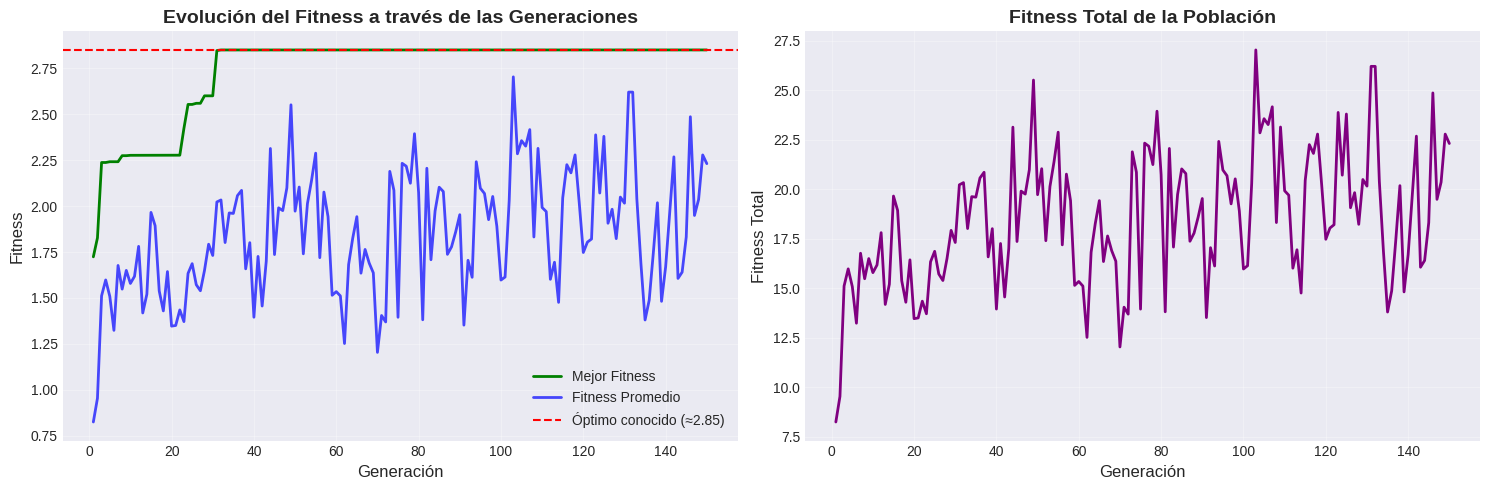

In [ ]:
# Gráfico de evolución del fitness
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Mejor fitness y fitness promedio
generaciones = range(1, len(ga.estadisticas['mejor_fitness']) + 1)
ax1.plot(generaciones, ga.estadisticas['mejor_fitness'],
         label='Mejor Fitness', linewidth=2, color='green')
ax1.plot(generaciones, ga.estadisticas['fitness_promedio'],
         label='Fitness Promedio', linewidth=2, color='blue', alpha=0.7)
ax1.axhline(y=2.85, color='red', linestyle='--', label='Óptimo conocido (≈2.85)')
ax1.set_xlabel('Generación', fontsize=12)
ax1.set_ylabel('Fitness', fontsize=12)
ax1.set_title('Evolución del Fitness a través de las Generaciones', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Fitness total de la población
ax2.plot(generaciones, ga.estadisticas['fitness_total'],
         linewidth=2, color='purple')
ax2.set_xlabel('Generación', fontsize=12)
ax2.set_ylabel('Fitness Total', fontsize=12)
ax2.set_title('Fitness Total de la Población', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2. Función Objetivo y Mejor Solución

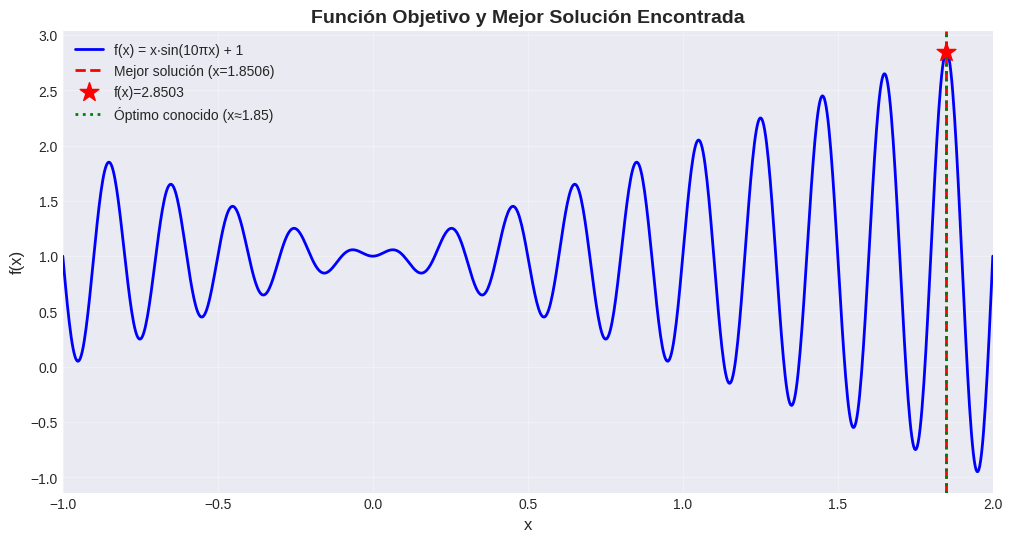

In [ ]:
# Graficar la función objetivo
x_vals = np.linspace(X_MIN, X_MAX, 1000)
y_vals = x_vals * np.sin(10 * PI * x_vals) + 1.0

plt.figure(figsize=(12, 6))
plt.plot(x_vals, y_vals, linewidth=2, label='f(x) = x·sin(10πx) + 1', color='blue')
plt.axvline(x=ga.mejor_historico.valor_real, color='red', linestyle='--',
            linewidth=2, label=f'Mejor solución (x={ga.mejor_historico.valor_real:.4f})')
plt.scatter([ga.mejor_historico.valor_real], [ga.mejor_historico.fitness],
            color='red', s=200, zorder=5, marker='*',
            label=f'f(x)={ga.mejor_historico.fitness:.4f}')
plt.axvline(x=1.85, color='green', linestyle=':', linewidth=2,
            label='Óptimo conocido (x≈1.85)')
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Función Objetivo y Mejor Solución Encontrada', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(X_MIN, X_MAX)
plt.show()

### 6.3. Distribución de la Población Final

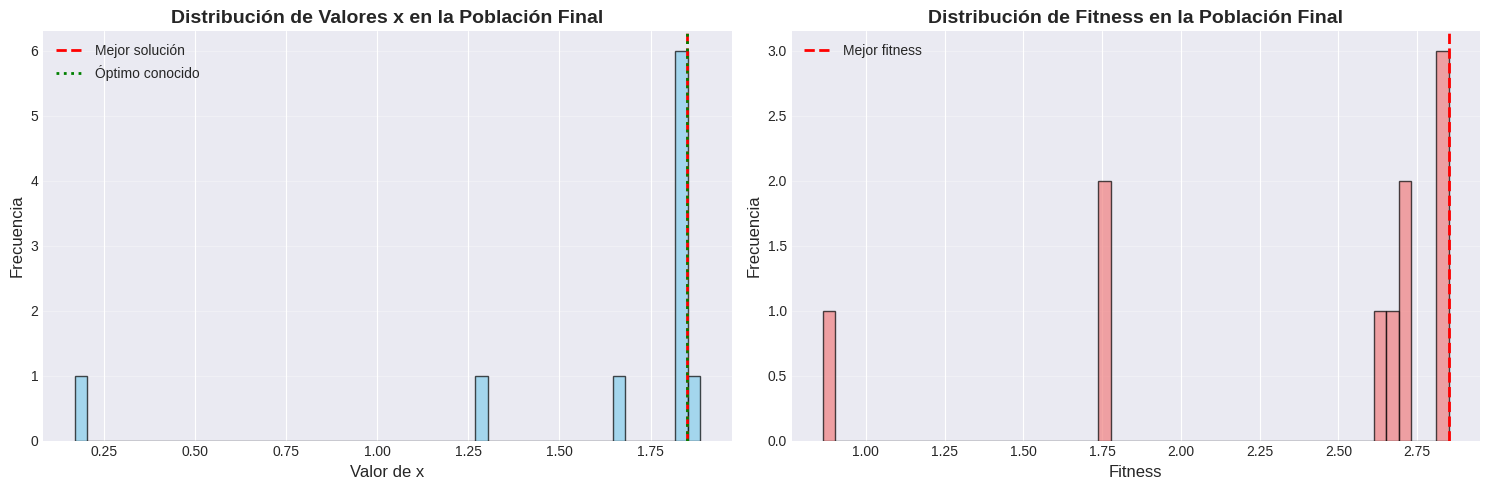

In [ ]:
# Distribución de valores x en la población final
valores_x_finales = [ind.valor_real for ind in ga.poblacion]
fitness_finales = [ind.fitness for ind in ga.poblacion]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de valores x
ax1.hist(valores_x_finales, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=ga.mejor_historico.valor_real, color='red', linestyle='--',
            linewidth=2, label='Mejor solución')
ax1.axvline(x=1.85, color='green', linestyle=':', linewidth=2,
            label='Óptimo conocido')
ax1.set_xlabel('Valor de x', fontsize=12)
ax1.set_ylabel('Frecuencia', fontsize=12)
ax1.set_title('Distribución de Valores x en la Población Final', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Histograma de fitness
ax2.hist(fitness_finales, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.axvline(x=ga.mejor_historico.fitness, color='red', linestyle='--',
            linewidth=2, label='Mejor fitness')
ax2.set_xlabel('Fitness', fontsize=12)
ax2.set_ylabel('Frecuencia', fontsize=12)
ax2.set_title('Distribución de Fitness en la Población Final', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Análisis Estadístico

### 7.1. Tabla de Resultados

In [ ]:
# Crear tabla de resultados
resultados = {
    'Métrica': [
        'Mejor x encontrado',
        'Mejor fitness encontrado',
        'Óptimo conocido (x)',
        'Óptimo conocido f(x)',
        'Error en x',
        'Error en fitness',
        'Generaciones ejecutadas',
        'Total de cruzamientos',
        'Total de mutaciones',
        'Precisión teórica'
    ],
    'Valor': [
        f"{ga.mejor_historico.valor_real:.10f}",
        f"{ga.mejor_historico.fitness:.10f}",
        "1.8500000000",
        "2.8500000000",
        f"{abs(ga.mejor_historico.valor_real - 1.85):.10f}",
        f"{abs(ga.mejor_historico.fitness - 2.85):.10f}",
        f"{MAX_GENERACIONES}",
        f"{ga.estadisticas['cruzamientos']}",
        f"{ga.estadisticas['mutaciones']}",
        f"{3.0/(2**22 - 1):.2e}"
    ]
}

df_resultados = pd.DataFrame(resultados)
print("\n" + "="*70)
print("TABLA DE RESULTADOS FINALES")
print("="*70)
print(df_resultados.to_string(index=False))
print("="*70)


TABLA DE RESULTADOS FINALES
                 Métrica        Valor
      Mejor x encontrado 1.8505866171
Mejor fitness encontrado 2.8502723664
     Óptimo conocido (x) 1.8500000000
    Óptimo conocido f(x) 2.8500000000
              Error en x 0.0005866171
        Error en fitness 0.0002723664
 Generaciones ejecutadas          150
   Total de cruzamientos          329
     Total de mutaciones         3236
       Precisión teórica     7.15e-07


### 7.2. Análisis de Convergencia

In [ ]:
# Análisis de convergencia
mejores = ga.estadisticas['mejor_fitness']
promedios = ga.estadisticas['fitness_promedio']

# Encontrar generación donde se alcanza el 95% del mejor fitness final
objetivo_95 = mejores[-1] * 0.95
gen_95 = next((i for i, v in enumerate(mejores) if v >= objetivo_95), None)

# Encontrar generación donde se alcanza el 99% del mejor fitness final
objetivo_99 = mejores[-1] * 0.99
gen_99 = next((i for i, v in enumerate(mejores) if v >= objetivo_99), None)

print("\nANÁLISIS DE CONVERGENCIA:")
print(f"  Generación donde se alcanza 95% del mejor: {gen_95 + 1 if gen_95 is not None else 'N/A'}")
print(f"  Generación donde se alcanza 99% del mejor: {gen_99 + 1 if gen_99 is not None else 'N/A'}")
print(f"  Mejora desde gen 1 hasta gen {MAX_GENERACIONES}: {mejores[-1] - mejores[0]:.6f}")
print(f"  Mejora promedio por generación: {(mejores[-1] - mejores[0])/MAX_GENERACIONES:.6f}")

# Diversidad (desviación estándar del fitness)
diversidad = np.std(fitness_finales)
print(f"\nDIVERSIDAD DE LA POBLACIÓN FINAL:")
print(f"  Desviación estándar del fitness: {diversidad:.6f}")
print(f"  Coeficiente de variación: {(diversidad/np.mean(fitness_finales))*100:.2f}%")


ANÁLISIS DE CONVERGENCIA:
  Generación donde se alcanza 95% del mejor: 31
  Generación donde se alcanza 99% del mejor: 31
  Mejora desde gen 1 hasta gen 150: 1.126460
  Mejora promedio por generación: 0.007510

DIVERSIDAD DE LA POBLACIÓN FINAL:
  Desviación estándar del fitness: 0.640136
  Coeficiente de variación: 27.01%


## 8. Comparación con Múltiples Ejecuciones

Ejecutamos el AG varias veces para evaluar su robustez.

In [ ]:
# Ejecutar múltiples veces
num_ejecuciones = 10
resultados_multiples = []

print(f"\nEjecutando {num_ejecuciones} veces el algoritmo genético...\n")

for i in range(num_ejecuciones):
    # Cambiar semilla para cada ejecución
    np.random.seed(i * 100)

    # Crear y ejecutar AG
    ga_temp = AlgoritmoGenetico()
    ga_temp.ejecutar(verbose=False)

    resultados_multiples.append({
        'ejecucion': i + 1,
        'mejor_x': ga_temp.mejor_historico.valor_real,
        'mejor_fitness': ga_temp.mejor_historico.fitness,
        'error_x': abs(ga_temp.mejor_historico.valor_real - 1.85),
        'error_fitness': abs(ga_temp.mejor_historico.fitness - 2.85)
    })

    print(f"Ejecución {i+1}: x={ga_temp.mejor_historico.valor_real:.6f}, "
          f"fitness={ga_temp.mejor_historico.fitness:.6f}")

# Análisis estadístico
df_multiples = pd.DataFrame(resultados_multiples)

print("\n" + "="*70)
print("ESTADÍSTICAS DE MÚLTIPLES EJECUCIONES")
print("="*70)
print(f"\nMejor x encontrado:")
print(f"  Media: {df_multiples['mejor_x'].mean():.6f}")
print(f"  Desv. estándar: {df_multiples['mejor_x'].std():.6f}")
print(f"  Mínimo: {df_multiples['mejor_x'].min():.6f}")
print(f"  Máximo: {df_multiples['mejor_x'].max():.6f}")

print(f"\nMejor fitness encontrado:")
print(f"  Media: {df_multiples['mejor_fitness'].mean():.6f}")
print(f"  Desv. estándar: {df_multiples['mejor_fitness'].std():.6f}")
print(f"  Mínimo: {df_multiples['mejor_fitness'].min():.6f}")
print(f"  Máximo: {df_multiples['mejor_fitness'].max():.6f}")

print(f"\nError promedio en x: {df_multiples['error_x'].mean():.6f}")
print(f"Error promedio en fitness: {df_multiples['error_fitness'].mean():.6f}")


Ejecutando 10 veces el algoritmo genético...

Inicializando población...
Población inicial creada con 10 individuos
Mejor individuo inicial: x=1.881790, fitness=2.018755

INICIANDO EVOLUCIÓN


EVOLUCIÓN COMPLETADA

Mejor solución encontrada:
  x = 1.8505401255
  f(x) = 2.8502737175
  Cromosoma: 1111001100111110111111

Estadísticas:
  Total de cruzamientos: 350
  Total de mutaciones: 3416
  Tiempo de ejecución: 0.0553 segundos

Óptimo conocido: x* ≈ 1.85, f(x*) ≈ 2.85
Error: 0.000540
Ejecución 1: x=1.850540, fitness=2.850274
Inicializando población...
Población inicial creada con 10 individuos
Mejor individuo inicial: x=1.849610, fitness=2.849472

INICIANDO EVOLUCIÓN


EVOLUCIÓN COMPLETADA

Mejor solución encontrada:
  x = 1.8505465628
  f(x) = 2.8502737660
  Cromosoma: 1111001100111111001000

Estadísticas:
  Total de cruzamientos: 336
  Total de mutaciones: 3408
  Tiempo de ejecución: 0.0607 segundos

Óptimo conocido: x* ≈ 1.85, f(x*) ≈ 2.85
Error: 0.000547
Ejecución 2: x=1.850547, fi

### 8.1. Visualización de Múltiples Ejecuciones

/tmp/ipykernel_8494/3586721914.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([df_multiples['mejor_x']], labels=['Mejor x'])
/tmp/ipykernel_8494/3586721914.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([df_multiples['mejor_fitness']], labels=['Mejor fitness'])


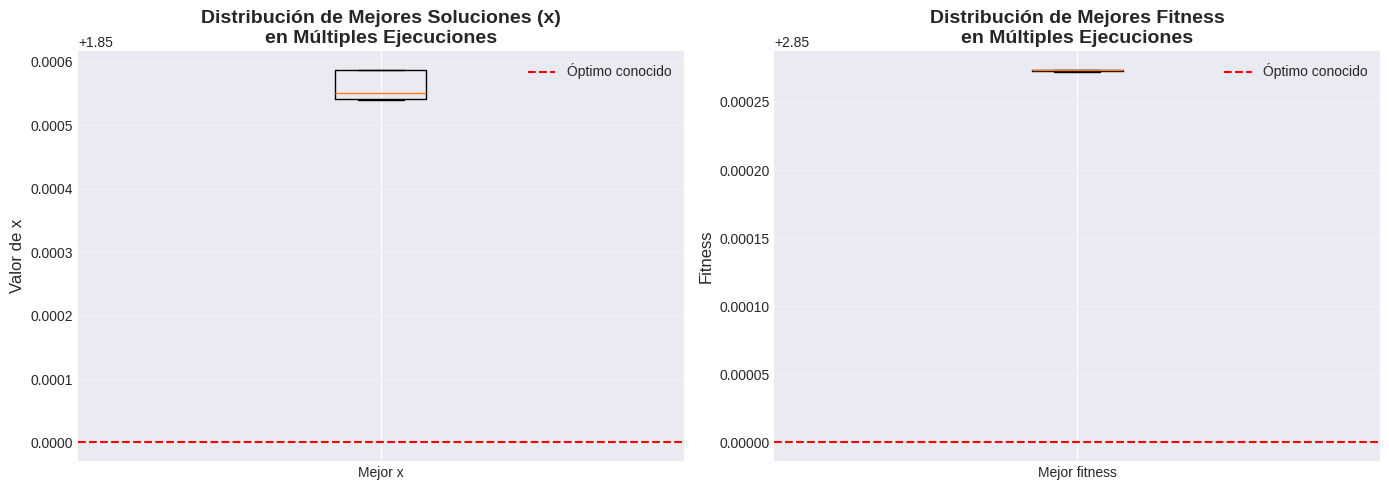

In [ ]:
# Box plots de múltiples ejecuciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot para x
ax1.boxplot([df_multiples['mejor_x']], labels=['Mejor x'])
ax1.axhline(y=1.85, color='red', linestyle='--', label='Óptimo conocido')
ax1.set_ylabel('Valor de x', fontsize=12)
ax1.set_title('Distribución de Mejores Soluciones (x)\nen Múltiples Ejecuciones',
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Box plot para fitness
ax2.boxplot([df_multiples['mejor_fitness']], labels=['Mejor fitness'])
ax2.axhline(y=2.85, color='red', linestyle='--', label='Óptimo conocido')
ax2.set_ylabel('Fitness', fontsize=12)
ax2.set_title('Distribución de Mejores Fitness\nen Múltiples Ejecuciones',
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Conclusiones

Este notebook implementa un **Algoritmo Genético clásico** para encontrar el máximo de la función:

$$f(x) = x \cdot \sin(10\pi x) + 1, \quad x \in [-1, 2]$$

### Resultados principales:

1. **Codificación binaria** de 22 bits proporciona precisión suficiente (≈7.15×10⁻⁷)
2. **Selección por ruleta** favorece individuos con mejor fitness
3. **Cruzamiento de un punto** permite exploración del espacio de búsqueda
4. **Mutación bit-flip** mantiene diversidad genética
5. **Elitismo** asegura que la mejor solución nunca se pierda

### Ventajas del AG:
- No requiere información del gradiente
- Robusto ante múltiples óptimos locales
- Fácil de implementar y adaptar

### Posibles mejoras:
- Implementar **cruzamiento multipunto** o **uniforme**
- Usar **selección por torneo** en lugar de ruleta
- Aplicar **presión de selección adaptativa**
- Implementar **mutación adaptativa** (probabilidad variable)
- Usar **codificación real** en lugar de binaria (más eficiente para problemas continuos)

---

**¡Experimente con diferentes parámetros y observe cómo afectan el rendimiento del algoritmo!**